## Business Problem
> Perusahaan ingin memprediksi customer yang berpotensi churn agar tim retention bisa melakukan intervensi lebih awal.

## Tujuan EDA
- Memahami struktur dan kualitas data
- Melihat pola dasar pada fitur-fitur utama
- Mencari faktor-faktor yang berhubungan dengan churn
- Menghasilkan insight yang bisa dipakai untuk strategi retention

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv('../dataset/raw/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
## Data Overview
print("Shape", df.shape)
display(df.head())
display(df.sample(5, random_state=42))
df.info()

Shape (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Data Quality Check
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nBlank values in TotalCharges:")
print((df['TotalCharges'].astype(str).str.strip() == '').sum())

Duplicate rows: 0

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Blank values in TotalCharges:
11


In [5]:
## Cleaning dasar
df.columns = df.columns.str.strip()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["ChurnFlag"] = df["Churn"].map({"Yes": 1, "No": 0})
df["SeniorCitizenLabel"] = df["SeniorCitizen"].map({1: "Senior", 0: "Non-Senior"})

display(df[["TotalCharges", "Churn", "ChurnFlag", "SeniorCitizen", "SeniorCitizenLabel"]].head())
print("Missing TotalCharges after conversion:", df["TotalCharges"].isnull().sum())

,TotalCharges,Churn,ChurnFlag,SeniorCitizen,SeniorCitizenLabel
0,29.85,No,0,0,Non-Senior
1,1889.50,No,0,0,Non-Senior
2,108.15,Yes,1,0,Non-Senior
3,1840.75,No,0,0,Non-Senior
4,151.65,Yes,1,0,Non-Senior


Missing TotalCharges after conversion: 11


## Target Analysis
Bagian ini melihat distribusi customer yang churn dan tidak churn.
Tujuannya untuk mengetahui apakah dataset imbalanced dan seberapa besar masalah churn.

,count,percent
Churn,,
No,5174,73.46
Yes,1869,26.54


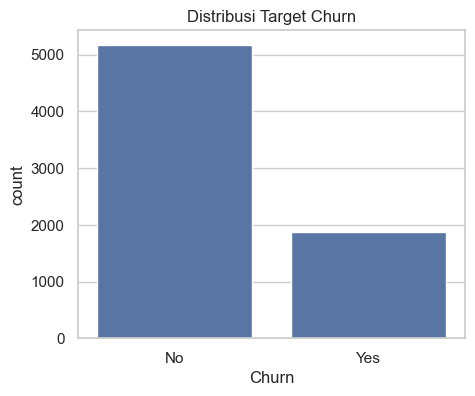

In [6]:
target_counts = df["Churn"].value_counts()
target_pct = df["Churn"].value_counts(normalize=True).mul(100).round(2)

display(pd.concat([target_counts, target_pct], axis=1, keys=["count", "percent"]))

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Churn")
plt.title("Distribusi Target Churn")
plt.show()

## Univariate Analysis
Bagian ini melihat distribusi tiap fitur satu per satu untuk memahami pola umum, sebaran, dan kemungkinan outlier.

In [7]:
# Statistik Numerik
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
display(df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


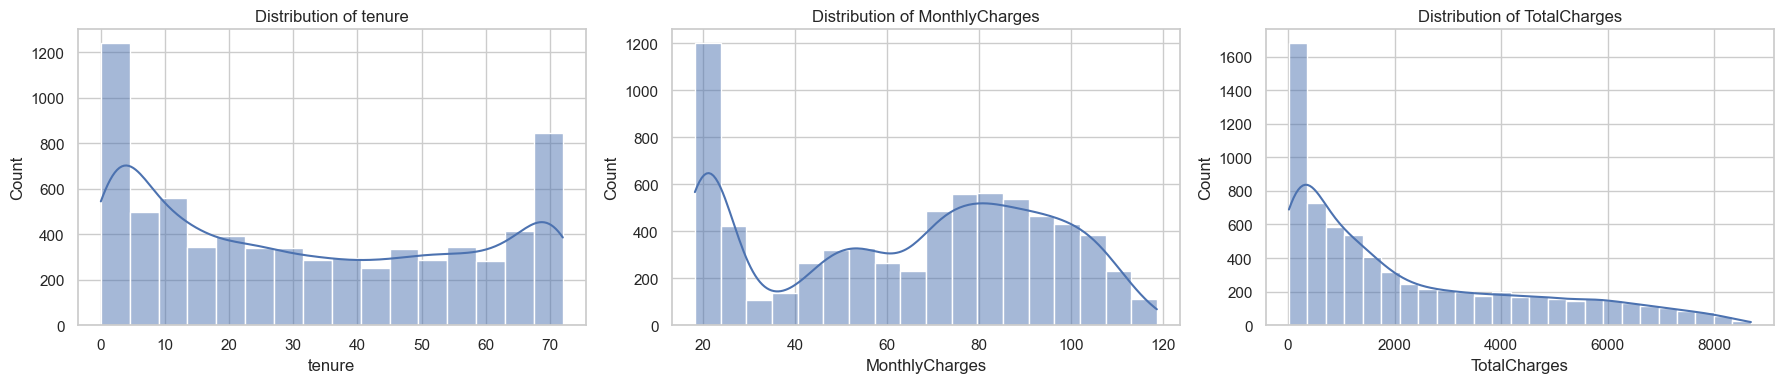

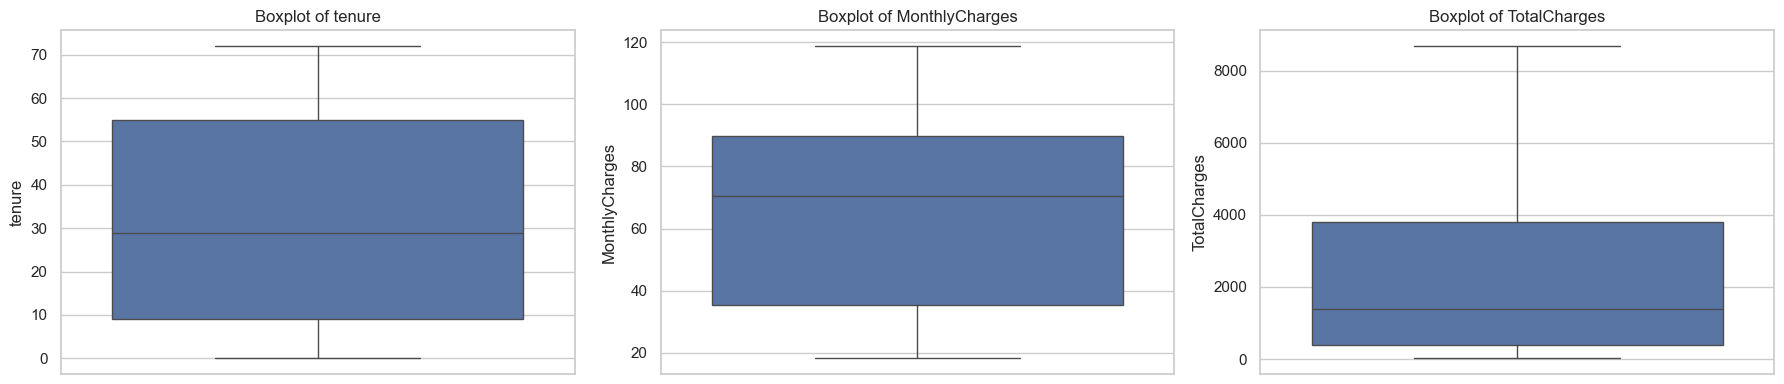

In [8]:
# Distribusi Numerik
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [9]:
# Distribusi Fitur Kategorikal
cat_cols = [col for col in df.select_dtypes(include=["object", "string"]).columns
            if col not in ["customerID", "Churn"]]

for col in cat_cols:    
    print(f"\n{col}")
    display(df[col].value_counts())


gender


gender
Male      3555
Female    3488
Name: count, dtype: int64


Partner


Partner
No     3641
Yes    3402
Name: count, dtype: int64


Dependents


...

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64


PaymentMethod


PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


SeniorCitizenLabel


SeniorCitizenLabel
Non-Senior    5901
Senior        1142
Name: count, dtype: int64

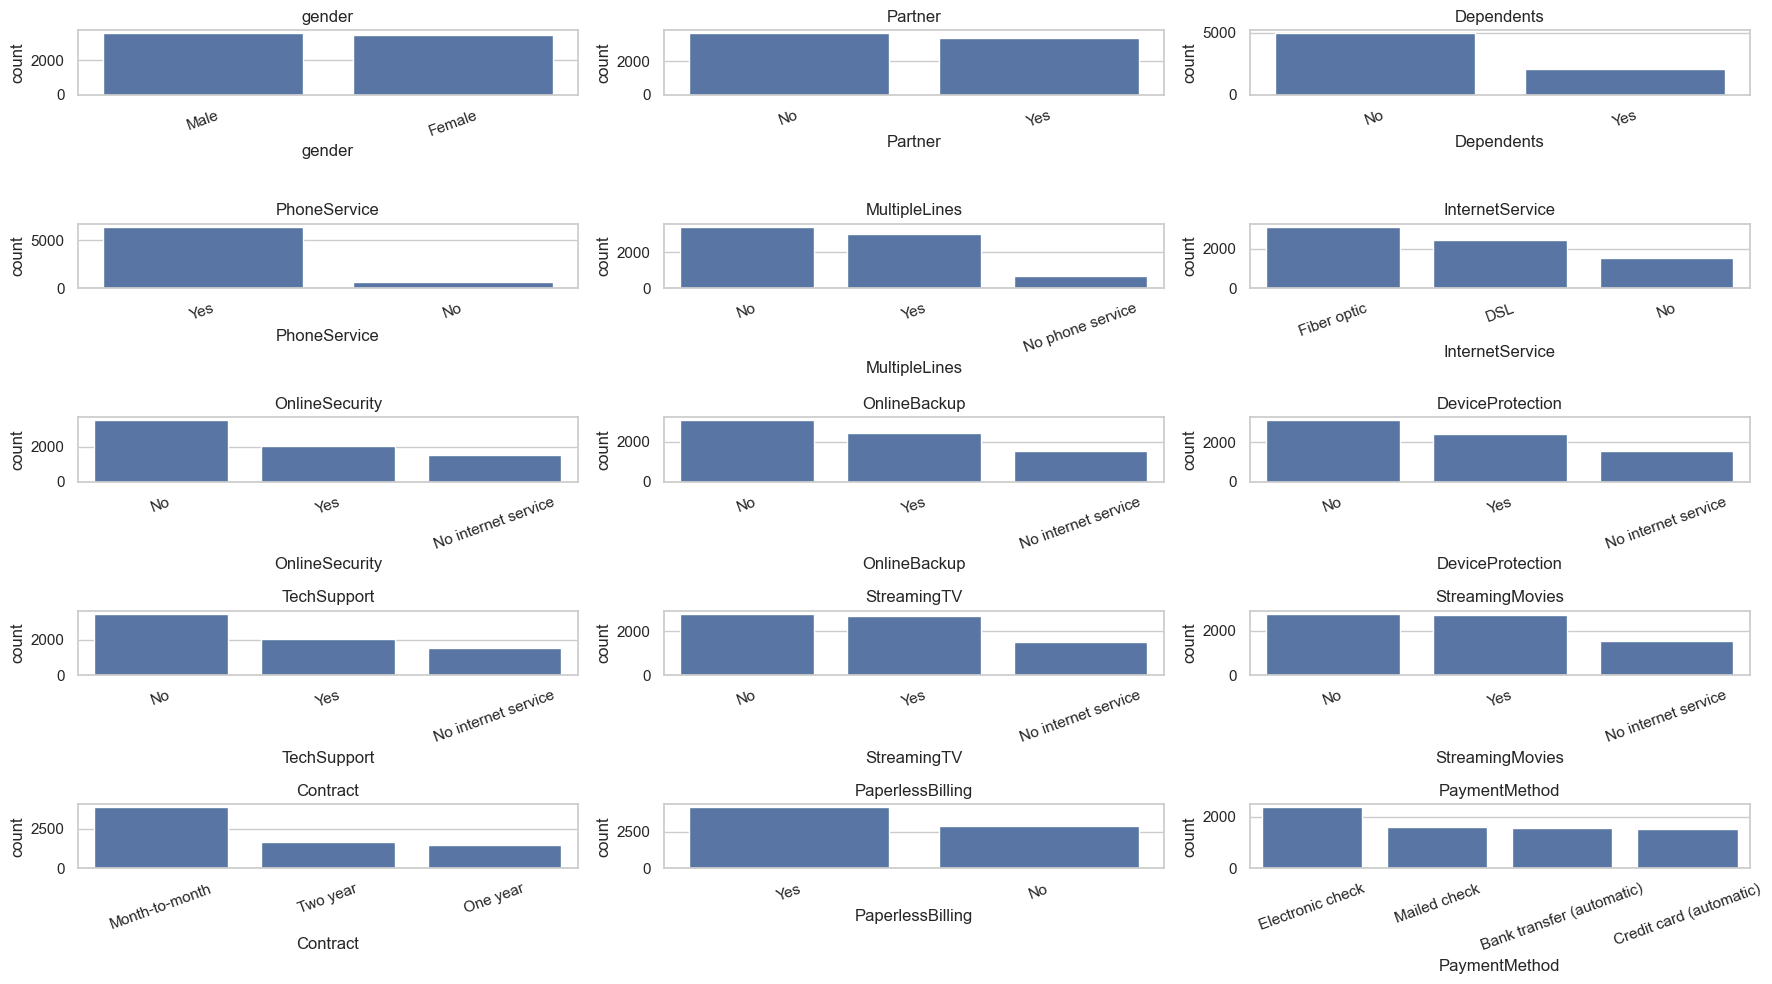

In [10]:
# Plot Fitur Kategorikal Penting
plot_cols = cat_cols

fig, axes = plt.subplots(5, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), plot_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Bivariate Analysis terhadap Churn
Bagian ini mencari fitur apa yang paling membedakan customer churn dan non-churn.
Hasilnya biasanya menjadi insight utama untuk tim retention.

gender
Female    26.92
Male      26.16
Name: churn_rate_%, dtype: float64

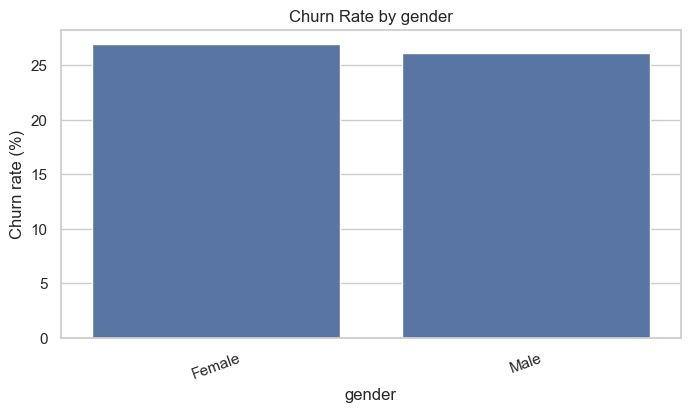

Partner
No     32.96
Yes    19.66
Name: churn_rate_%, dtype: float64

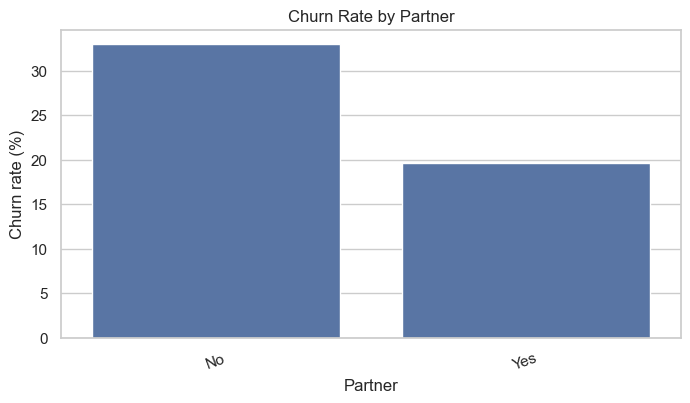

Dependents
No     31.28
Yes    15.45
Name: churn_rate_%, dtype: float64

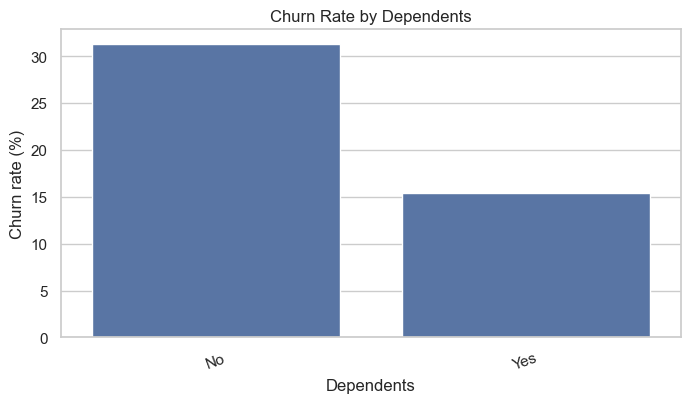

PhoneService
Yes    26.71
No     24.93
Name: churn_rate_%, dtype: float64

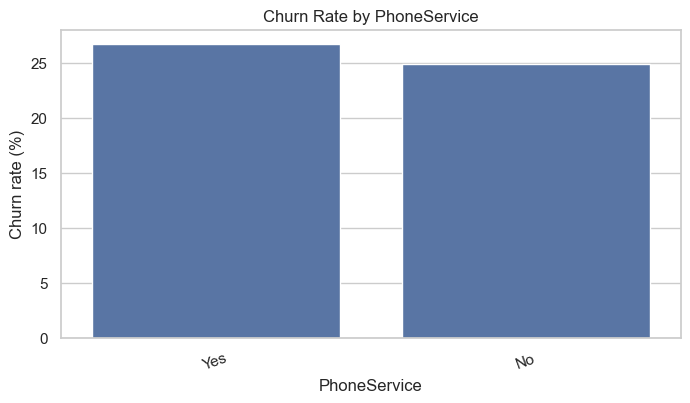

MultipleLines
Yes                 28.61
No                  25.04
No phone service    24.93
Name: churn_rate_%, dtype: float64

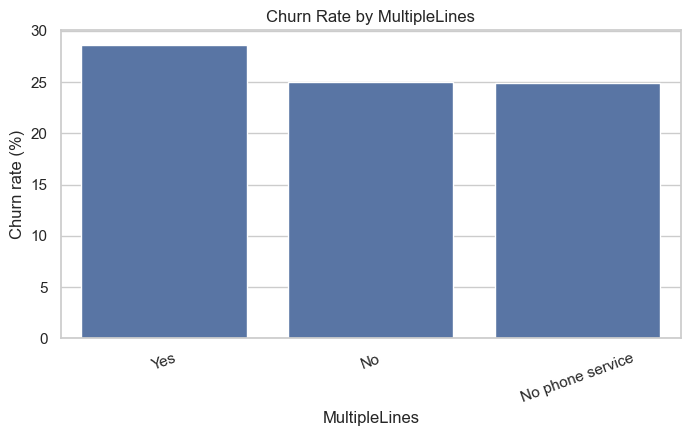

InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: churn_rate_%, dtype: float64

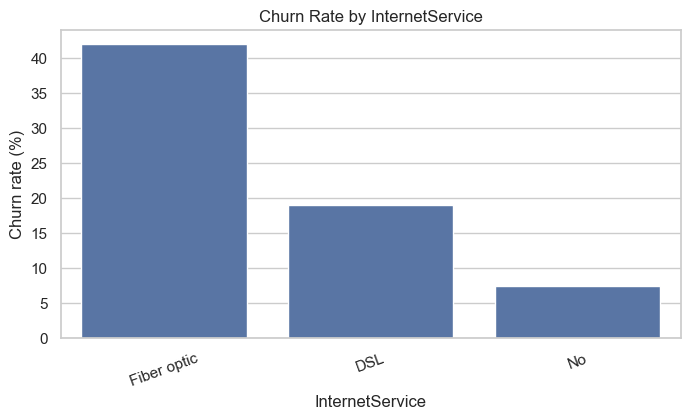

OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: churn_rate_%, dtype: float64

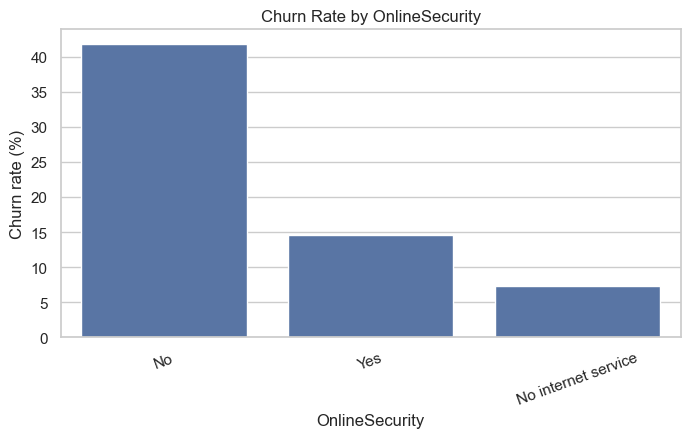

OnlineBackup
No                     39.93
Yes                    21.53
No internet service     7.40
Name: churn_rate_%, dtype: float64

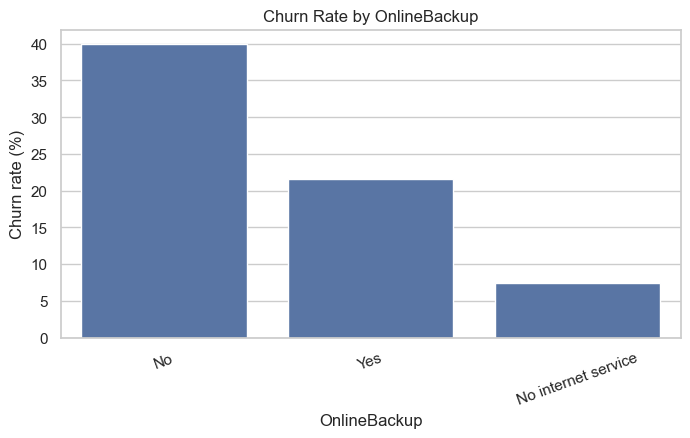

DeviceProtection
No                     39.13
Yes                    22.50
No internet service     7.40
Name: churn_rate_%, dtype: float64

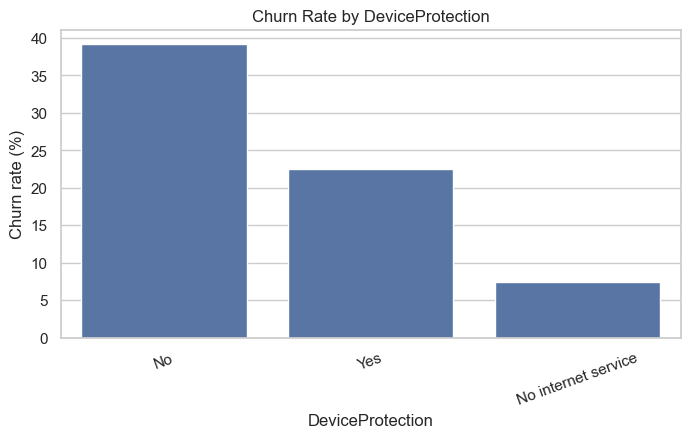

TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: churn_rate_%, dtype: float64

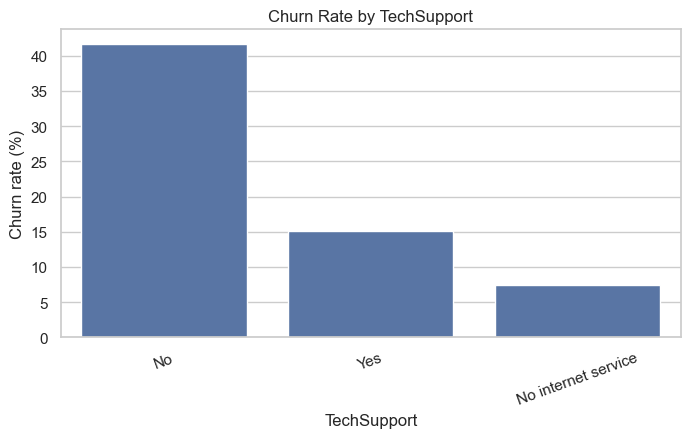

StreamingTV
No                     33.52
Yes                    30.07
No internet service     7.40
Name: churn_rate_%, dtype: float64

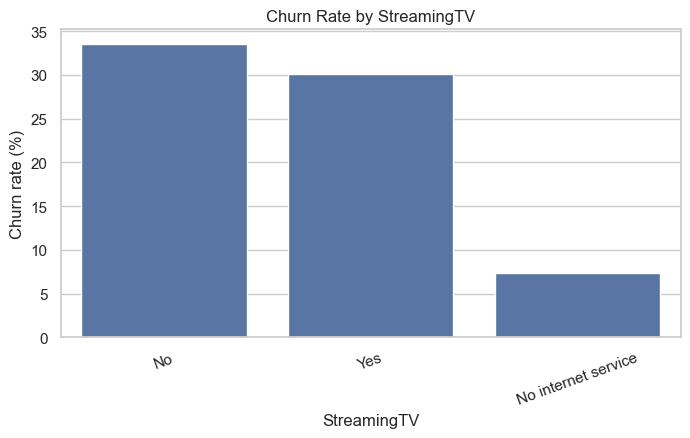

StreamingMovies
No                     33.68
Yes                    29.94
No internet service     7.40
Name: churn_rate_%, dtype: float64

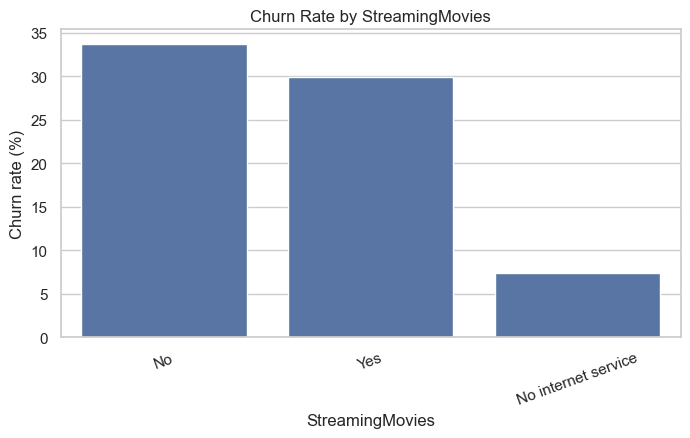

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: churn_rate_%, dtype: float64

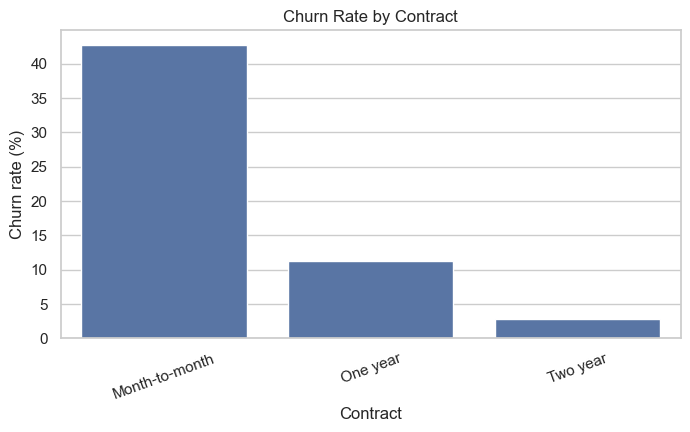

PaperlessBilling
Yes    33.57
No     16.33
Name: churn_rate_%, dtype: float64

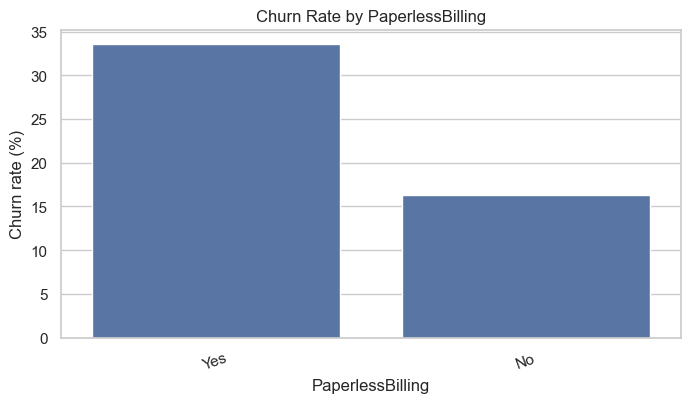

PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: churn_rate_%, dtype: float64

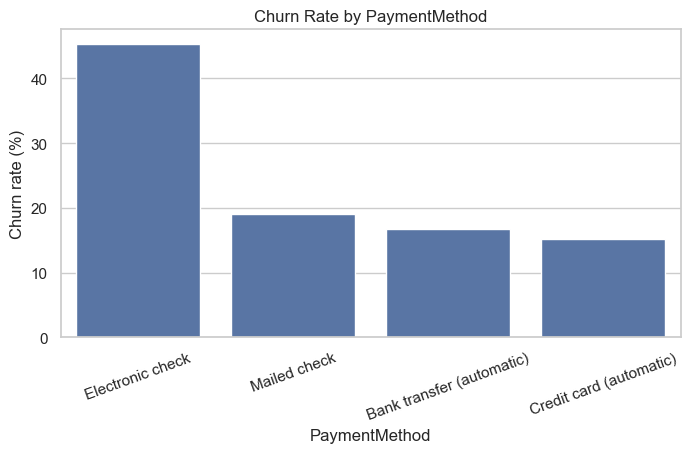

SeniorCitizenLabel
Senior        41.68
Non-Senior    23.61
Name: churn_rate_%, dtype: float64

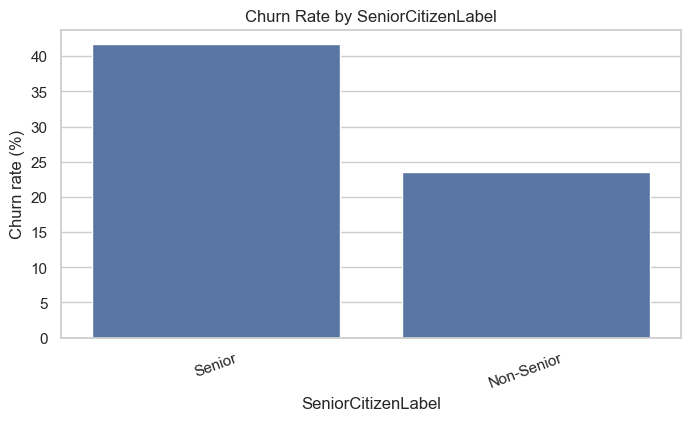

In [11]:
# Churn rate berdasarkan fitur kategorikal
for col in cat_cols:
    churn_rate = df.groupby(col)["ChurnFlag"].mean().sort_values(ascending=False).mul(100).round(2)
    display(churn_rate.rename("churn_rate_%"))

    plt.figure(figsize=(8, 4))
    sns.barplot(x=churn_rate.index, y=churn_rate.values)
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn rate (%)")
    plt.xticks(rotation=20)
    plt.show()

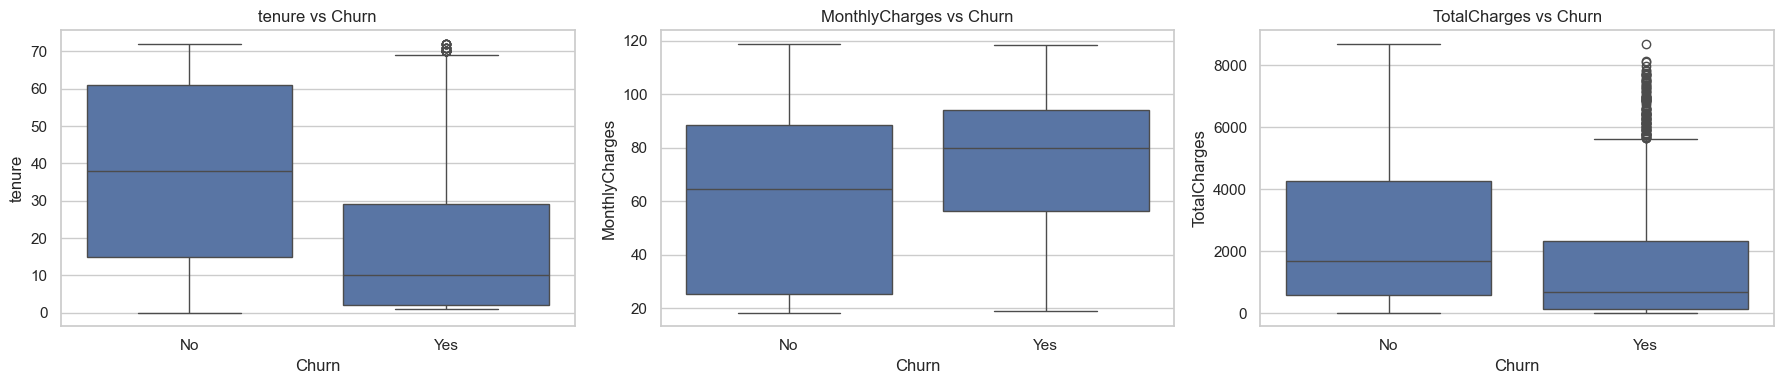

In [12]:
# Fitur numerik vs churn
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax)
    ax.set_title(f"{col} vs Churn")

plt.tight_layout()
plt.show()

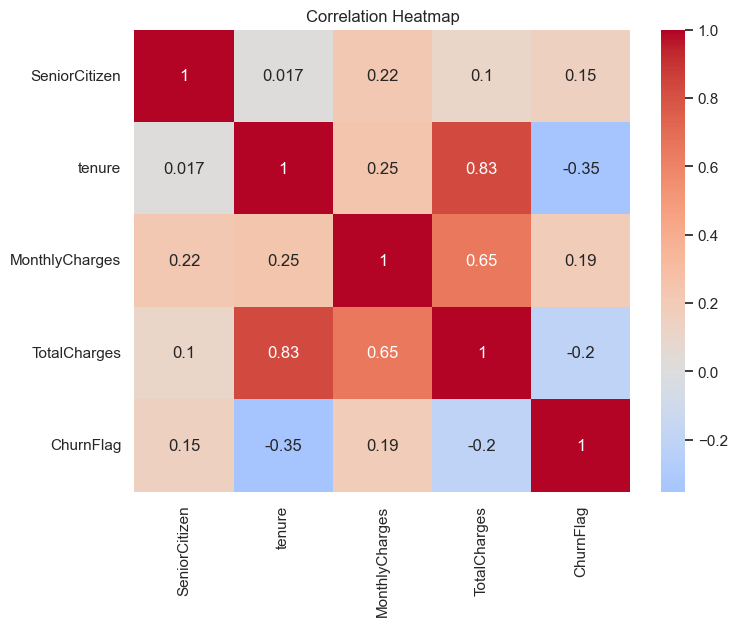

In [13]:
# Korelasi fitur numerik
corr_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "ChurnFlag"]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## Insight Summary
1. Customer dengan risiko churn tertinggi adalah mereka yang memakai kontrak month-to-month, metode bayar electronic check, layanan internet fiber optic, dan tenure rendah.

2. Pola customer yang cenderung bertahan adalah Customer yang cenderung bertahan biasanya punya kontrak jangka panjang, tenure lebih tinggi, serta hubungan rumah tangga yang lebih stabil seperti partner dan dependents.


3. Implikasi bisnis untuk tim retention:
> Fokus retention pada Mont-to-month contract menjadi penawaran long-term contract dengan diskon selama 1 tahun pertama, atau bisa lakukan penawaran 6-month contract dengan diskon yang lebih kecil daripada long-term contract.
>
> Untuk customer yang menggunakan Fiber Optic, kita bisa meningkatkan kualitas pelayanan atau adjust harga nya
>
> Memberikan promo untuk customer yang menggunakan automatic payment
>
> Memberikan program spesial untuk senior citizen

4. Ide preprocessing atau feature engineering untuk modeling:
> 1. Encode binary: Gender, Partner, Dependents, dan PaperlessBilling menjadi 0 dan 1 (Preprocessing)
> 2. Encode categorical: InternetService, Contract, PaymentMethod → one-hot atau label encode
> 3. Feature baru bisa dibuat dari TotalCharges/tenure (average charge per month)
> 4. Handle missing TotalCharges (jika ada)